# ELO LASSO Regression

In [29]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import sys
from scipy import stats


from sklearn.metrics import mean_squared_error
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_predict, cross_val_score

from elo_grad import EloEstimator, Regressor
from elo_grad.sklearn import SKEloEstimator

print(f'Python {sys.version} on {sys.platform}.')


Python 3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:19:24) [Clang 18.1.8 ] on darwin.


In [41]:
# import data
train_set = pd.read_csv("../data/processed/train_set.csv")
train_set = pd.DataFrame(train_set)

train_set['date_game'] = pd.to_datetime(train_set['date_game'])
#train_set.set_index('game_date', inplace=True)


In [6]:
train_set.columns

Index(['date_game', 'game_id', 'team_id_main', 'team_abbreviation_main',
       'team_wins_losses_main', 'pts_main', 'matchup_main', 'wl_main',
       'fgm_main', 'fga_main', 'fg_pct_main', 'fg3m_main', 'fg3a_main',
       'fg3_pct_main', 'ftm_main', 'fta_main', 'ft_pct_main', 'oreb_main',
       'dreb_main', 'ast_main', 'stl_main', 'blk_main', 'tov_main', 'pf_main',
       'plus_minus_main', 'team_id_opp', 'team_abbreviation_opp',
       'team_wins_losses_opp', 'pts_opp', 'team_name_opp', 'matchup_opp',
       'wl_opp', 'fgm_opp', 'fga_opp', 'fg_pct_opp', 'fg3m_opp', 'fg3a_opp',
       'fg3_pct_opp', 'ftm_opp', 'fta_opp', 'ft_pct_opp', 'oreb_opp',
       'dreb_opp', 'reb_opp', 'ast_opp', 'stl_opp', 'blk_opp', 'tov_opp',
       'pf_opp', 'plus_minus_opp', 'season_id', 'is_playoffs',
       'elo_main_pre_538', 'elo_main_post_538', 'win_equiv', 'elo_opp_pre_538',
       'elo_opp_post_538', 'game_result', 'forecast'],
      dtype='object')

In [42]:
# Create dummy variables
dummy_cols = pd.get_dummies(train_set['wl_main'])
train_set['wl_main'] = dummy_cols['W'].astype(int)



In [43]:
scaled_predictors = ['fgm_main', 'fga_main', 'fg_pct_main',
       'fg3m_main', 'fg3a_main', 'fg3_pct_main', 'ftm_main', 'fta_main',
       'ft_pct_main', 'oreb_main', 'dreb_main', 
       'ast_main',
       'stl_main', 'blk_main', 'tov_main', 'pf_main', 'pts_main',
       'plus_minus_main'] 

train_set[scaled_predictors] = stats.zscore(train_set[scaled_predictors])

all_predictors = ['fgm_main', 'fga_main', 'fg_pct_main',
       'fg3m_main', 'fg3a_main', 'fg3_pct_main', 'ftm_main', 'fta_main',
       'ft_pct_main', 'oreb_main', 'dreb_main', 
       'ast_main',
       'stl_main', 'blk_main', 'tov_main', 'pf_main', 'pts_main',
       'plus_minus_main', 'is_playoffs'] 


In [44]:
# Input DataFrame with sorted index of timestamps
# and columns entity_1 | entity_2 | score | home
# where score = 1 if player_1 won and score = 0 if
# player_2 won.
estimator = EloEstimator(
    k_factor=20, 
    default_init_rating=1505,
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="wl_main",
    date_col="date_game",
    # Set k-factor/step-size to 1 for the home advantage regressor
    additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.4) for p in all_predictors]
)
# Get expected scores
expected_scores = estimator.predict_proba(train_set)
# Get final ratings (of form (timestamp, rating)) for home advantage
ratings = estimator.model.ratings

## Get predictions and ratings

In [45]:
# Fit the estimator
model_fit = estimator.fit(train_set)

# Get predictions
preds = estimator.predict(train_set)

In [46]:
sorted(estimator.model.ratings.items(), key=lambda item: item[1][1], reverse=True)[:100]


[('TOR', (Timestamp('2007-11-02 00:00:00'), 1644.689161957213)),
 ('WAS', (Timestamp('2007-11-02 00:00:00'), 1631.4822191174212)),
 ('CHI', (Timestamp('2007-11-01 00:00:00'), 1583.3646992543302)),
 ('DET', (Timestamp('2007-11-02 00:00:00'), 1580.3855947625284)),
 ('DAL', (Timestamp('2007-11-01 00:00:00'), 1570.326384256916)),
 ('IND', (Timestamp('2007-11-01 00:00:00'), 1562.7157620514306)),
 ('ATL', (Timestamp('2007-04-18 00:00:00'), 1547.3590606563553)),
 ('PHI', (Timestamp('2007-11-01 00:00:00'), 1539.5632440652353)),
 ('SAC', (Timestamp('2007-11-02 00:00:00'), 1539.1058814524458)),
 ('MIA', (Timestamp('2007-11-02 00:00:00'), 1534.193426210159)),
 ('VAN', (Timestamp('2001-04-21 00:00:00'), 1530.905660461109)),
 ('CHH', (Timestamp('2002-10-29 00:00:00'), 1524.8004503873713)),
 ('MIL', (Timestamp('2007-11-02 00:00:00'), 1523.4116188532935)),
 ('NOK', (Timestamp('2007-04-21 00:00:00'), 1522.3543051671184)),
 ('LAC', (Timestamp('2007-11-02 00:00:00'), 1507.9992204877249)),
 ('CLE', (Time

In [51]:
sorted_ratings = sorted(estimator.model.ratings.items(), key=lambda item: item[1][1], reverse=True)[:100]
ratings_df = pd.DataFrame(sorted_ratings, columns=['team_abbreviation_main', 'rating', 'date_game'])
ratings_df['rating'] = ratings_df['rating'].apply(lambda x: x[1])

ValueError: 3 columns passed, passed data had 2 columns

In [57]:
print(sorted_ratings[:3])

ratings_df = pd.DataFrame(columns=['team_abbreviation_main', 'date_game', 'rating'])

ratings_df["team_abbreviation_main"] = [a for a,b,c in sorted_ratings]
ratings_df['date_game'] = [b for a,b,c in sorted_ratings]
ratings_df['rating'] = [c for a,b,c in sorted_ratings]

[('TOR', (Timestamp('2007-11-02 00:00:00'), 1644.689161957213)), ('WAS', (Timestamp('2007-11-02 00:00:00'), 1631.4822191174212)), ('CHI', (Timestamp('2007-11-01 00:00:00'), 1583.3646992543302))]


ValueError: not enough values to unpack (expected 3, got 2)

In [23]:
train_set['team_abbreviation_main'].unique()

array(['BOS', 'HOU', 'CHI', 'MIL', 'NJN', 'DET', 'POR', 'LAL', 'CLE',
       'DAL', 'DEN', 'SAC', 'SEA', 'LAC', 'ATL', 'NYK', 'IND', 'CHH',
       'MIA', 'MIN', 'ORL', 'VAN', 'TOR', 'SAS', 'PHI', 'UTA', 'GSW',
       'WAS', 'MEM', 'NOH', 'CHA', 'PHO', 'NOK'], dtype=object)

ValueError: x must be a label or position

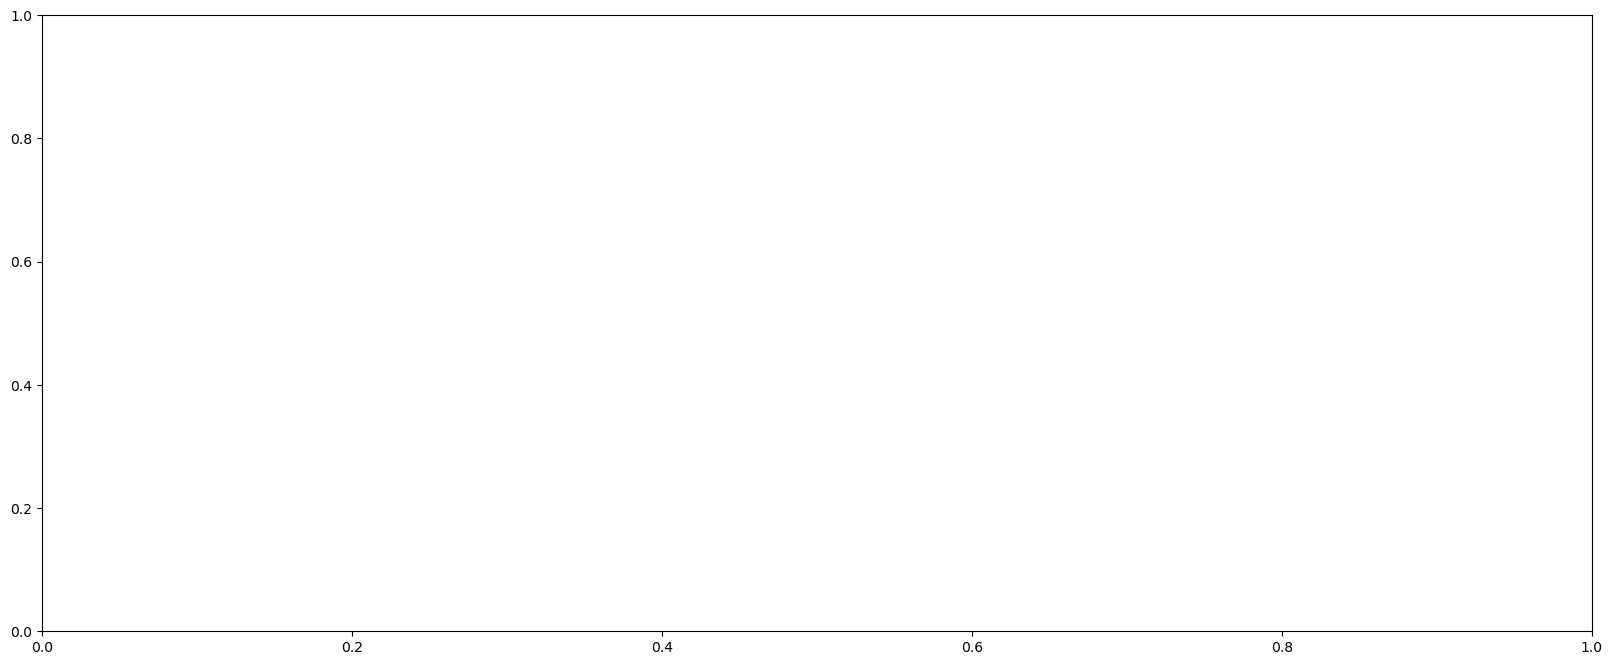

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
estimator.plot(['TOR', 'GSW'], ax=ax)
ax.set_title("Elo Ratings for TOR and BOS")
ax.set_xlabel("Date")
ax.set_ylabel("Elo Rating")
plt.xlim(pd.to_datetime("1981-05-05"), pd.to_datetime("2015-06-16"))
plt.ylim(1200, 1800)
plt.tight_layout()
plt.show()

## Evaluate the predictions

In [26]:
y_val_pred = estimator.predict_proba(train_set)[:, 1]
print(f"Validation set log-loss: {log_loss(train_set['wl_main'], y_val_pred):.4f}")

Validation set log-loss: 0.6916


In [33]:
confusion_matrix(train_set['wl_main'], y_val_pred.round())

array([[9477, 7799],
       [7781, 9497]])

### Check the calibration

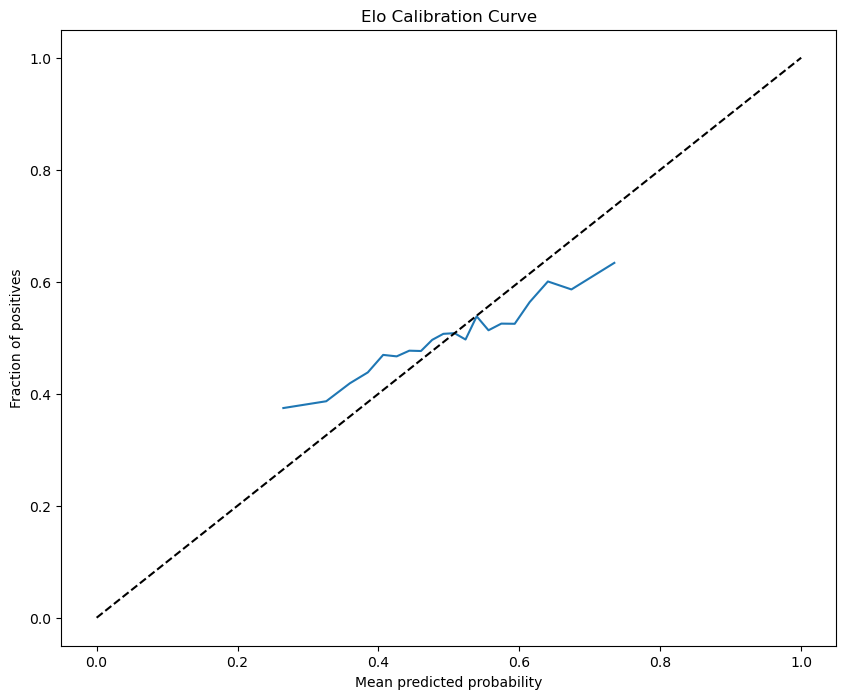

In [28]:
prob_true, prob_pred = calibration_curve(train_set['wl_main'], y_val_pred, n_bins=20, strategy='quantile')

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(prob_pred, prob_true)
ax.plot([0, 1], [0, 1], color='black', linestyle='--')
ax.set(
    title='Elo Calibration Curve',
    xlabel='Mean predicted probability',
    ylabel='Fraction of positives',
)

plt.show()


### Grid search

In [35]:
gs = GridSearchCV(
    estimator=SKEloEstimator(entity_cols=('team_abbreviation_main', 'team_abbreviation_opp'), score_col='wl_main'), 
    param_grid={
        'beta': [200],
        'k_factor': [10, 100],
    },
    cv=TimeSeriesSplit(n_splits=5),
)


In [40]:
train_set[all_predictors].head()

,fgm_main,fga_main,fg_pct_main,fg3m_main,fg3a_main,fg3_pct_main,ftm_main,fta_main,ft_pct_main,oreb_main,dreb_main,ast_main,stl_main,blk_main,tov_main,pf_main,pts_main,plus_minus_main,is_playoffs
0,0.626349,1.527730,-0.421281,-1.500822,-1.823618,-2.040499,-0.559640,-0.770682,0.514326,2.801432,-0.087243,0.094066,-0.653432,-0.009858,0.905643,-0.363650,-0.064138,0.222144,4.192543
1,0.797241,1.992640,-0.556881,-1.500822,-1.667831,-2.040499,-1.308679,-1.501961,0.372401,1.432947,-1.225753,0.094066,2.264382,-0.751170,-1.245859,-0.576803,-0.293452,-0.222144,4.192543
2,-0.569899,0.365454,-0.963680,-0.824001,-1.667831,4.004387,0.339207,0.691876,-0.621075,0.064462,-1.415505,-1.164301,-0.653432,1.102110,-1.484915,-1.216262,-0.675641,0.148096,4.192543
3,0.626349,0.016771,0.731318,-1.500822,-1.512043,-2.040499,-1.758102,-1.623840,-1.361112,0.292543,0.861516,-0.984534,-0.653432,0.731454,1.622811,0.915267,-0.522766,-0.148096,4.192543
4,-2.278824,-0.331912,-2.590879,-1.500822,-1.823618,-2.040499,0.489015,0.569996,-0.073650,1.432947,-0.087243,-2.242901,-0.653432,1.472766,1.383755,-0.789956,-0.369890,-1.703101,4.192543


In [ ]:
gs.fit(train_set[all_predictors], train_set['wl_main'])
pl.DataFrame(gs.cv_results_).sort('mean_test_score', descending=False)

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/Applications/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/narwhals/_pandas_like/utils.py", line 672, in select_columns_by_name
    return df[column_names]  # type: ignore[index]
           ~~^^^^^^^^^^^^^^
  File "/Applications/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/pandas/core/frame.py", line 4108, in __getitem__
    indexer = self.columns._get_indexer_strict(key, "columns")[1]
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Applications/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/pandas/core/indexes/base.py", line 6200, in _get_indexer_strict
    s

### Comparing the log loss with and without the regressors

In [ ]:
y_val_pred_home = elo_home.predict_proba(X_val)[:, 1]
print(f"Validation set log-loss: {log_loss(X_val['result'], y_val_pred_home):.4f}")

We can also visualise the home advantage effect over time.



In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
elo_home.plot(['home'], ax=ax)
plt.show()